# Задание 6. Применение микролокального анализа в томографии : лямбда-томография. Внутренняя задача томографии.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from numpy.fft import ifft2, fft2, fft, fftshift, ifft, ifftshift, fftn, ifftn
from scipy.special import erf
from sem2utilities import adjradon2d

## 1. Tomographie Lambda

Dans cette tâche, nous allons découvrir un exemple d'application de l'analyse microlocale en tomographie - la tomographie lambda (la raison du terme "lambda" sera claire plus loin). Rappelons que la formule de Radon dans le cas 2D est la suivante :

\begin{align}
    f(x) = \dfrac{1}{4\pi}R^* H[\dfrac{d}{ds}Rf], \, x\in R^2, 
\end{align}

où $R^*$ est la transformation de Radon adjointe, et $H$ est la transformation de Hilbert.

Comme nous l'avons déjà mentionné, cette formule est applicable si nous avons accès aux données complètes $Rf(s,\theta)$, $s\in R$, $\theta\in S^1$. Dans le cas contraire, un des inconvénients principaux de cette formule est sa **non-localité** (en raison de la transformation de Hilbert). Il est logique que si nous voulons obtenir la valeur $f(x)$ en un point spécifique $x$, les mesures devraient être effectuées le long des rayons qui intersectent $x$ et son voisinage aussi petit que possible. Comme on peut le voir ci-dessus, ce n'est pas le cas dans la formule de Radon (pourquoi c'est le cas a été expliqué lors des cours).

Pour obtenir une formule locale, nous pouvons remplacer la transformation de Hilbert par un autre filtre. C'est avec cette idée que les méthodes de tomographie lambda ont vu le jour (voir [référence](https://www.pnas.org/doi/pdf/10.1073/pnas.0906391106)), dont la formule est la suivante :

\begin{align}
\Lambda f(x) = \mathcal{R}^*\left[-\frac{d^2}{ds^2} \mathcal{R}f(s,\theta) \right](x).
\end{align}

**Exercice 1.1** Démontrer que la formule pour $\Lambda f(x)$ est locale. *Indication :* rappelez-vous comment $R^*(\dfrac{d^2}{ds^2} h)$ s'exprime en termes de $R^* h$.

**Exercice 1.2** En utilisant les matériaux des cours, montrez ce qui suit. Soit $f\in \mathcal{E}'(R^2)$ (une fonction généralisée à support compact). Montrez que

 1. \begin{equation}
    \mathrm{singsupp} f = \mathrm{singsupp}\, \Lambda f,
    \end{equation}
    

 2. \begin{equation}
    \mathrm{WF}(f) = \mathrm{WF}(\Lambda f),
    \end{equation}
     où $WF$ désigne le front d'onde.

Локальность формулы и гарантия сохранения волнового фронта позволяет восстанавливать скачки в неизвестном сигнале даже при ограниченных данных. Ниже мы рассмотрим случай внутренней задачи, когда известны лучевые данные $Rf(s,\theta)$, $s\in (-R, R)$, \, $\theta\in S^1$, $R$ - радиус сканируемой области ROI (region-of-interest).

**Exercice 1.3** Programmez la formule pour $\Lambda f(x)$. *Note:* en utilisant la transformation de Fourier, vous pouvez échanger la dérivée $d^2/ds^2$ et la projection inverse $R^*$. De plus, pour calculer la dérivée, vous pouvez utiliser un schéma discret ou, par exemple, des méthodes spectrales (voir l'annexe pdf de l'exercice). (+0.1 point pour le calcul des dérivées par méthodes spectrales - pour la vitesse).

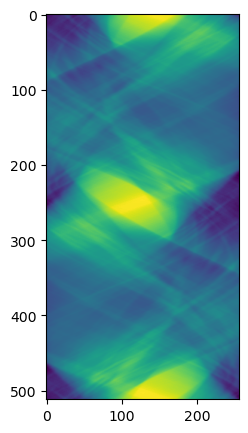

In [5]:
# download and read data

ntheta_roi = 512
nshift_roi = 256

r_supp = 1.0
r_roi = 0.5

filename_roi = 'roi-lambda-tomography.bin'
proj_data_roi = np.reshape(np.fromfile(filename_roi, dtype=float), (ntheta_roi, nshift_roi))

fig, axs = plt.subplots(1, 1, figsize=(12, 5), sharey=True)
plot1 = axs.imshow(proj_data_roi)
plt.show()

In [ ]:
# YOUR CODE HERE 

In [6]:
filename_full = 'covid-resized-masked_0.bin'

In [8]:
# roi data

ntheta_roi = 512
nshift_roi = 256
proj_data_roi = np.reshape(np.fromfile(filename_roi, dtype=float), (ntheta_roi, nshift_roi))

ntheta_full = 512
nshift_full = 512
proj_data_full = np.reshape(np.fromfile(filename_full, dtype=float), (ntheta_full, nshift_full))

appended_data_roi = np.zeros((512, 512))
for i in range(512):
    appended_data_roi[i, 128:-128] = proj_data_roi[i, :]
    appended_data_roi[i, :128] = proj_data_roi[i, 0]
    appended_data_roi[i, -128:] = proj_data_roi[i, 255]


**Exercice 1.4 (facultatif)** Montrez que généralement le problème interne de la tomographie n'a pas de solution unique. Autrement dit, la transformation de Radon $R : C_0^{\infty}(\Omega) \rightarrow C^{\infty}((-r,r) \times S^1)$ n'est pas injective, où $\Omega$ est une boule ouverte unitaire dans $R^2$ centrée en zéro, et $r\in (0,1)$.

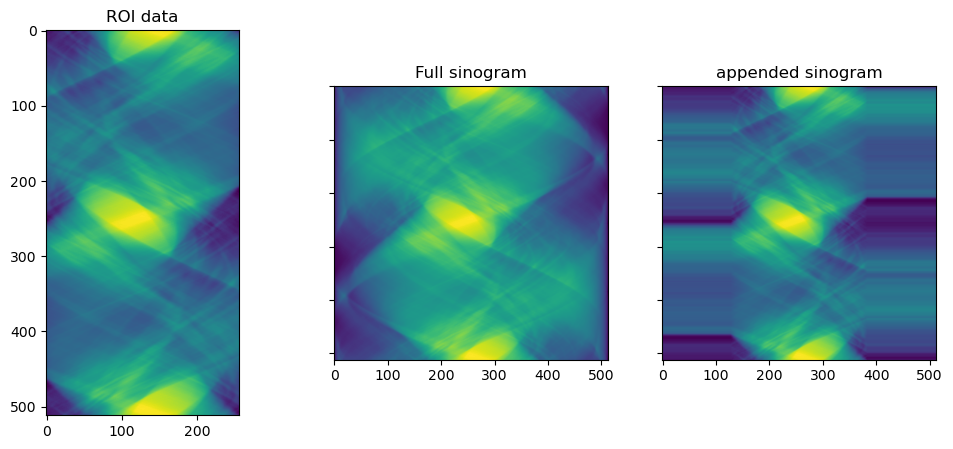

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

plot1 = axs[0].imshow(proj_data_roi)
axs[0].set_title('ROI data')
plot2 = axs[1].imshow(proj_data_full)
axs[1].set_title('Full sinogram')
plot3 = axs[2].imshow(appended_data_roi)
axs[2].set_title('appended sinogram')

plt.show()


In [10]:
# test that R*(sinogram_roi)_ROI = R*(sinogram_full)|_ROI

adj_roi = adjradon2d(proj_data_roi, npixels = 512, s_rad = 0.5, dom_rad = 1.0)
adj_full = adjradon2d(proj_data_full, npixels = 512, s_rad = 1.0, dom_rad = 1.0)

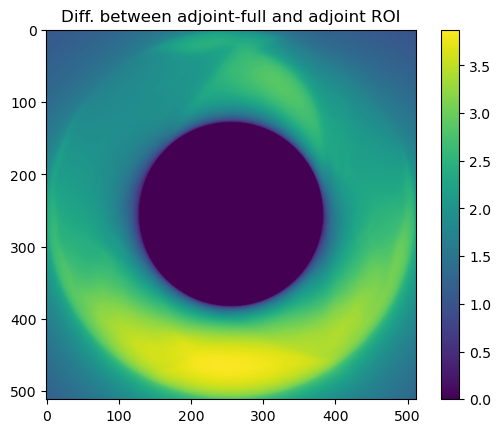

In [11]:
plt.imshow(adj_full - adj_roi)
plt.title("Diff. between adjoint-full and adjoint ROI")
plt.colorbar()
plt.show()

Conclusion : les adjoints coïncident dans la ROI, ce qui doit se produire dans le problème de tomographie interne.

Formule de $\lambda-$tomographie :
$$\mathcal{L}f(x)=\mathcal{R}^*\left[-\frac{d^2}{ds^2} \mathcal{R}f(s,\theta) \right](x).$$
Algorithme :
1. Prendre la dérivée seconde.
2. Appliquer la transformée de Radon adjointe $R^*$.

In [12]:
# calc (minus second derivative via two-point scheme)

derivative = np.zeros_like(proj_data_roi)
h = 1.0 / nshift_roi # stepsize

# second derivative for interior points
for j in range(1, nshift_roi-1):
    derivative[:,j] = -(proj_data_roi[:,j-1] +
                        proj_data_roi[:,j+1] -
                        2. * proj_data_roi[:,j]) / h ** 2

# second derivative on the boundaries
derivative[:, 0] = derivative[:, 1].copy()
derivative[:,-1] = derivative[:,-2].copy()

In [13]:
lambda_rec = adjradon2d(projections=derivative, npixels = 512, s_rad = 0.5, dom_rad = 1.0)

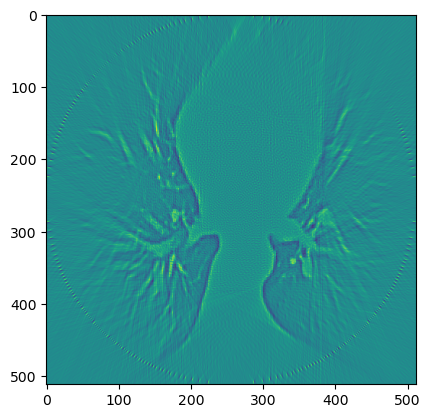

In [14]:
# lambda-tomography - discrete derivative approach

plt.imshow(lambda_rec)
plt.show()

Pour "vérifier" la bonne exécution de l'algorithme, nous aimerions comparer le résultat avec l'inversion standard de la transformation de Radon. Pour cela, nous utiliserons l'inversion standard FBP.

In [15]:
# construction of mask for spectral laplacian

# test

#npixels = 512
#lin = np.linspace(-1,1, npixels)

# func exp(- 1/(r-a)^2)
#m_x, m_y = np.meshgrid(lin, -lin)
#rr = np.sqrt(m_x**2 + m_y**2)
#mask = np.zeros((npixels, npixels))

#r0 = 0.3
#mask[rr < r0] = np.exp(-1. / (1000 *(rr[rr < r0]-r0)**2))

#plt.imshow(mask)
#plt.colorbar()
#plt.show()

# func erf-hat (not optimal implementation)

def centered_erf_hat(rad, outer_rad, inner_rad, Lparam = 1.0):
    
    if (rad >= outer_rad):
        return 0.0
    if (rad <= inner_rad):
        return 1.0
    
    rel_rad = 2. * (outer_rad - rad) / (outer_rad - inner_rad) - 1. # relative radius [-1,1]
    val = 0.5 * (1 + erf(Lparam * rel_rad / np.sqrt(1-rel_rad**2)))
    return val

    

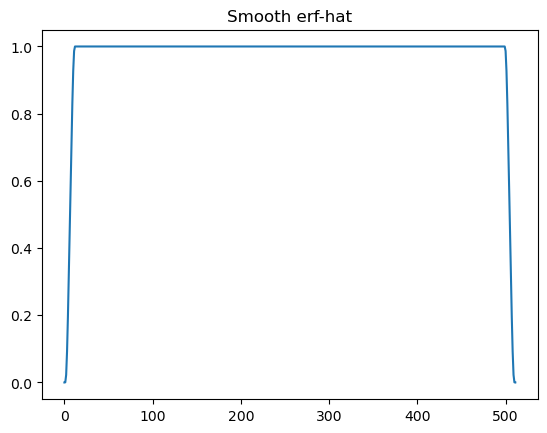

/tmp/ipykernel_163439/1111029153.py:20: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  freq_array = fftshift(range(npixels)).astype(np.float)


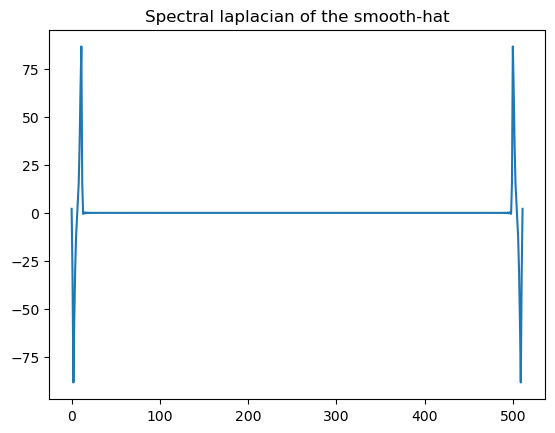

In [16]:
# spectral laplacian test of the centered-erf-hat

npixels = 512
lin = np.linspace(-1., 1., npixels)

smooth_hat = np.zeros_like(lin)
for i in range(npixels):
    smooth_hat[i] = centered_erf_hat(np.abs(lin[i]), outer_rad = 1, inner_rad = 0.95, Lparam = 1.5)
    
plt.plot(smooth_hat)
plt.title("Smooth erf-hat")
plt.show()

# spectral laplacian of the smooth hat

sampling_rate = npixels / 2.0 
nyq = sampling_rate / 2.0                # Nyquist-frequency - half of the sampling rate
df  = sampling_rate / npixels            # frequency step 

freq_array = fftshift(range(npixels)).astype(np.float)
freq_array[freq_array >= (npixels / 2)] -= npixels
freq_array *= df

RF = freq_array**2
DF = RF.copy()

# 3. apply (Fourier) filter - laplacian
fourier_transform = fftshift(fft(ifftshift(smooth_hat)))
filtered_data = np.multiply(fourier_transform, RF)

lap_hat =  ifftshift(ifft(fftshift(filtered_data))).real

plt.plot(lap_hat)
plt.title("Spectral laplacian of the smooth-hat")
plt.show()



In [24]:
def spectral_lambda(npixels, data, s_rad, rad):
    # compute adjoint
    adjoint_roi = adjradon2d(data, npixels, s_rad=s_rad, dom_rad = rad)
    
    plt.imshow(adjoint_roi)
    plt.show()
    
    # assemble smooth mask
    lin = np.linspace(-1., 1., npixels)
    m_x, m_y = np.meshgrid(lin, -lin)
    rr = np.sqrt(m_x**2 + m_y**2)
    mask = np.zeros_like(rr)
    for i in range(npixels):
        for j in range(npixels):
            mask[i,j] = centered_erf_hat(rr[i,j], outer_rad = 0.95, inner_rad = 0.85, Lparam = 1.5)
    
    adjoint_roi *= mask  # apply smoothing mask to regularize boundaries of the adjoint
    plt.imshow(adjoint_roi)
    plt.show()

    # 2. create Fourier filter

    sampling_rate = npixels / (2.0 * rad)
    nyq = sampling_rate / 2.0                # Nyquist-frequency - half of the sampling rate
    df  = sampling_rate / npixels            # frequency step 

    freq_array = fftshift(range(npixels)).astype(float)
    freq_array[freq_array >= (npixels / 2)] -= npixels
    freq_factor_x, freq_factor_y = np.meshgrid(freq_array, -freq_array)
    freq_factor_x *= df
    freq_factor_y *= df

    RF_sq = (freq_factor_x**2 + freq_factor_y**2)

    # 3. apply (Fourier) filter - spectral laplacian
    fourier_transform = fftshift(fft2(ifftshift(adjoint_roi)))
    filtered_data = np.multiply(fourier_transform, RF_sq)

    result =  ifftshift(ifft2(fftshift(filtered_data)))

    return result


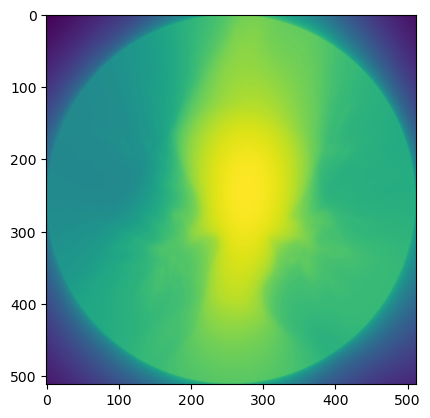

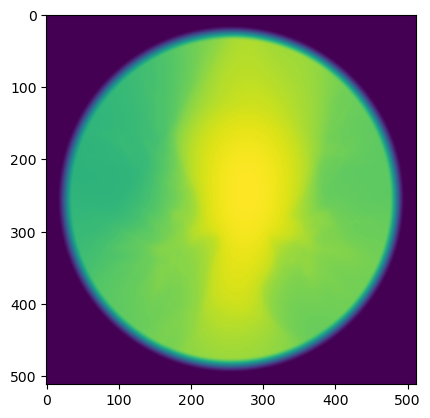

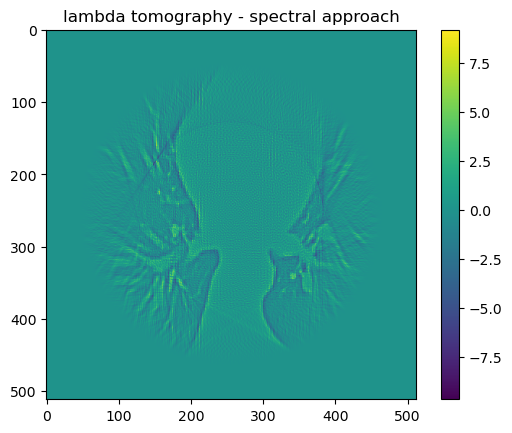

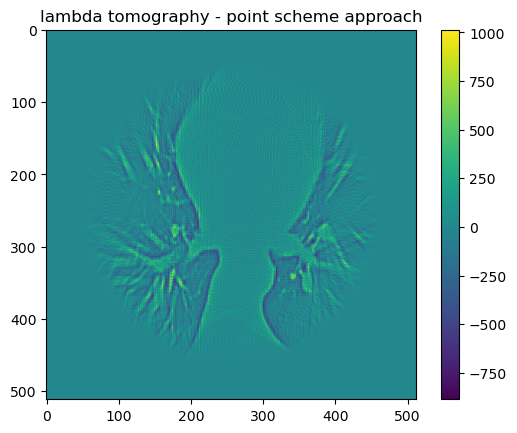

In [25]:
npixels = 512
#lambda_test = spectral_lambda(npixels, proj_data_roi, s_rad = 0.5, rad = 1.0)
lambda_test = spectral_lambda(npixels, appended_data_roi, s_rad = 2.0, rad = 2.0)

lin = np.linspace(-1.0, 1.0, npixels)
m_x, m_y = np.meshgrid(lin, -lin)
rr = np.sqrt(m_x**2 + m_y**2)
mask = np.zeros_like(rr)
for i in range(npixels):
    for j in range(npixels):
        mask[i,j] = centered_erf_hat(rr[i,j], outer_rad = 0.84, inner_rad = 0.7, Lparam = 1.5)

plt.imshow(lambda_test.real * mask)
plt.title('lambda tomography - spectral approach')
plt.colorbar()
plt.show()

lambda_rec = adjradon2d(derivative, npixels, s_rad=0.5, dom_rad = 1.0)
plt.imshow(lambda_rec * mask)
plt.title('lambda tomography - point scheme approach')
plt.colorbar()
plt.show()

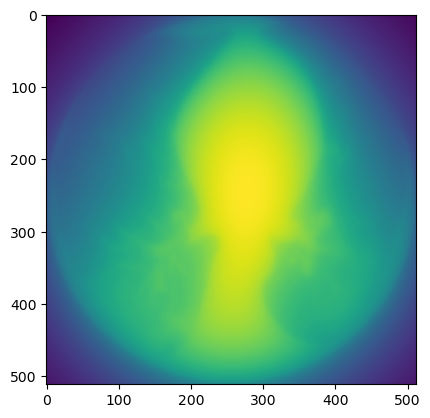

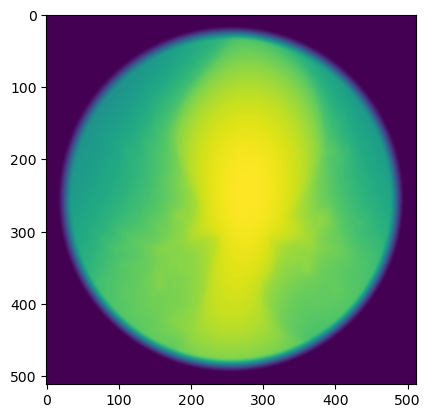

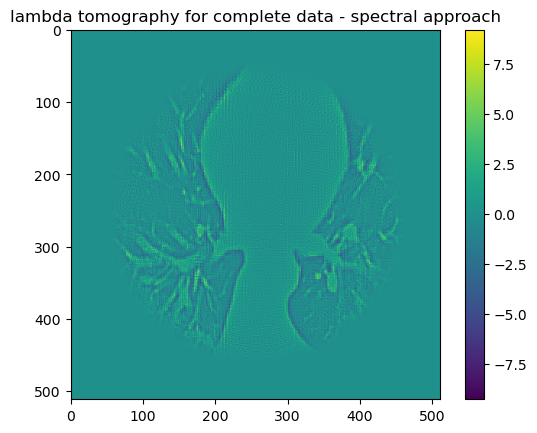

In [28]:
npixels = 512
lambda_test_full = spectral_lambda(npixels, proj_data_full, s_rad = 2.0, rad = 2.0)

# mask generation
lin = np.linspace(-1.0, 1.0, npixels)
m_x, m_y = np.meshgrid(lin, -lin)
rr = np.sqrt(m_x**2 + m_y**2)
mask = np.zeros_like(rr)
for i in range(npixels):
    for j in range(npixels):
        mask[i,j] = centered_erf_hat(rr[i,j], outer_rad = 0.84, inner_rad = 0.7, Lparam = 1.5)


plt.imshow(np.real(lambda_test_full * mask))
plt.title('lambda tomography for complete data - spectral approach')
plt.colorbar()
plt.show()


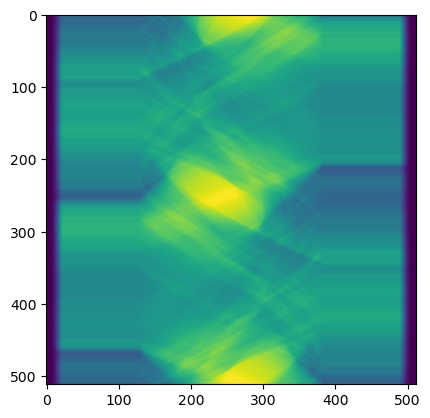

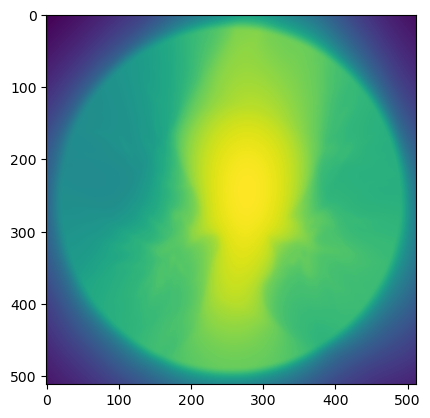

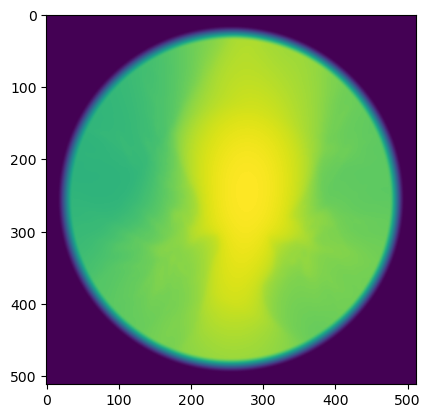

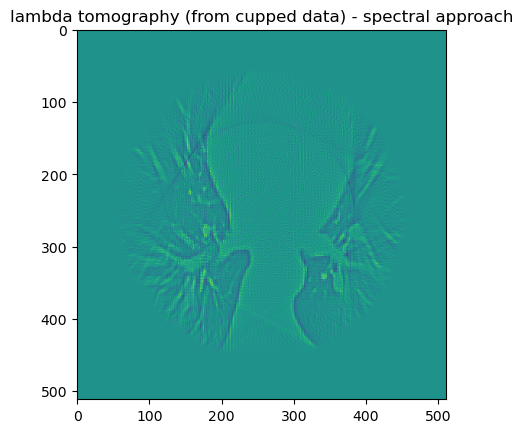

In [29]:
# test on pre-smoothing boundaries in projection data

ntheta_appended_cupped = 512
nshift_appended_cupped = 512

lin = np.linspace(-1., 1., nshift_appended_cupped)
smooth_hat = np.zeros_like(lin)
for i in range(nshift_appended_cupped):
    smooth_hat[i] = centered_erf_hat(np.abs(lin[i]), outer_rad = 1.0, inner_rad = 0.9, Lparam = 1.5)

cupped_proj_data = appended_data_roi
for i in range(ntheta_appended_cupped):
    cupped_proj_data[i, :] = cupped_proj_data[i, :] * smooth_hat

plt.imshow(cupped_proj_data)
plt.show()

# output image size
npixels = 512
lambda_test_cupped = spectral_lambda(npixels, cupped_proj_data, s_rad = 1.0, rad = 1.0)

lin = np.linspace(-1.0, 1.0, npixels)
m_x, m_y = np.meshgrid(lin, -lin)
rr = np.sqrt(m_x**2 + m_y**2)
mask = np.zeros_like(rr)
for i in range(npixels):
    for j in range(npixels):
        mask[i,j] = centered_erf_hat(rr[i,j], outer_rad = 0.79, inner_rad = 0.75, Lparam = 1.0)

plt.imshow(lambda_test_cupped.real * mask)
plt.title('lambda tomography (from cupped data) - spectral approach')
#plt.colorbar()
plt.show()

# Conclusion: no effect...


In [33]:
from skimage.transform import iradon

In [34]:
# FBP reconstructions from incomplete data
reconstruction_fbp_roi = iradon(proj_data_roi.transpose(), theta=np.linspace(0, 360, 512))

# FBP reconstructions from full data
reconstruction_fbp_full = iradon(proj_data_full.transpose(), theta=np.linspace(0, 360, 512))


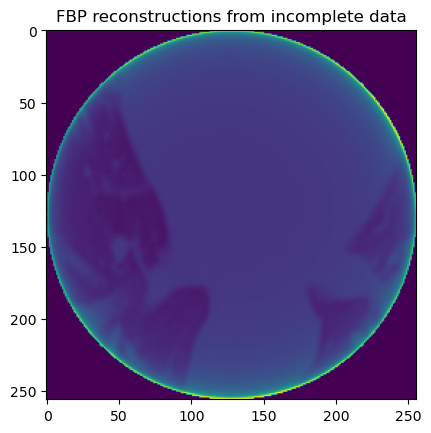

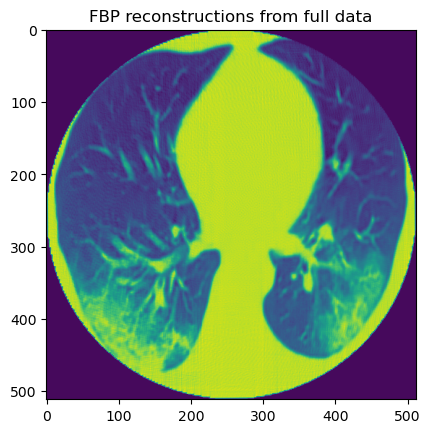

In [35]:
plt.imshow(reconstruction_fbp_roi)
plt.title("FBP reconstructions from incomplete data")
plt.show()

plt.imshow(reconstruction_fbp_full)
plt.title("FBP reconstructions from full data")
plt.show()

